In [1]:
# Python Standard Library
import sys
from os import mkdir
from os.path import join
from os.path import isdir
from shutil import rmtree

# Community Modules
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

# My Modules
sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du

rng = np.random.default_rng(1415)

2026-03-26 21:06:50.005493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-26 21:06:50.029820: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-26 21:06:50.036958: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-26 21:06:50.055294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 21:06:52.139452: W tensorflow/compiler/tf2

In [2]:
wvl, df_meta, spectra, spectra_signal, spectra_noise = du.load_dataset()

num_wvl = wvl.size
num_spectra = spectra.shape[0]

In [3]:
# new_SNR = 25
# new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
# new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
# new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
# new_spectra = spectra_signal + new_noise

In [4]:
new_SNR_vals = [1, 2, 5, 10, 25, 100]

for new_SNR in new_SNR_vals:
    print("new_SNR", new_SNR)
    new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
    new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
    new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
    new_spectra = spectra_signal + new_noise

    for i in tqdm(range(num_spectra)):
        i_row_series = df_meta.loc[i]
        i_spectra = spectra[i]
        i_spectra_signal = spectra_signal[i]
        i_spectra_noise = spectra_noise[i]
        i_new_noise = new_noise[i]
    
        i_specsnr = ms.SpectrumSNR(
            i_row_series["SN Name"],
            i_row_series["SN Subtype"],
            i_row_series["Spectrum Phase"],
            wvl,
            i_spectra)
        # i_specsnr.execute_algorithm(i_row_series)
        i_specsnr.execute_algorithm(i_row_series, new_noise=i_new_noise)
        
        df_meta.loc[i, f"{new_SNR}_new_measured_SNR"] = i_specsnr.SNR
        df_meta.loc[i, f"{new_SNR}_new_measured_N"] = i_specsnr.N

new_SNR 1


100%|██████████| 3574/3574 [04:18<00:00, 13.81it/s]


new_SNR 2


100%|██████████| 3574/3574 [04:18<00:00, 13.82it/s]


new_SNR 5


...

100%|██████████| 3574/3574 [04:19<00:00, 13.79it/s]


new_SNR 25


100%|██████████| 3574/3574 [04:22<00:00, 13.61it/s]


new_SNR 100


100%|██████████| 3574/3574 [04:20<00:00, 13.73it/s]


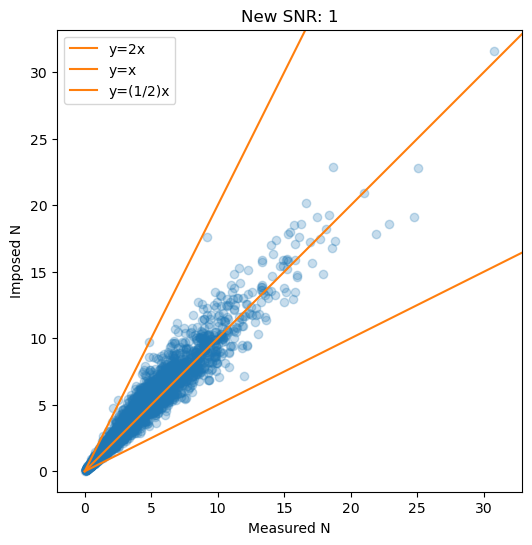

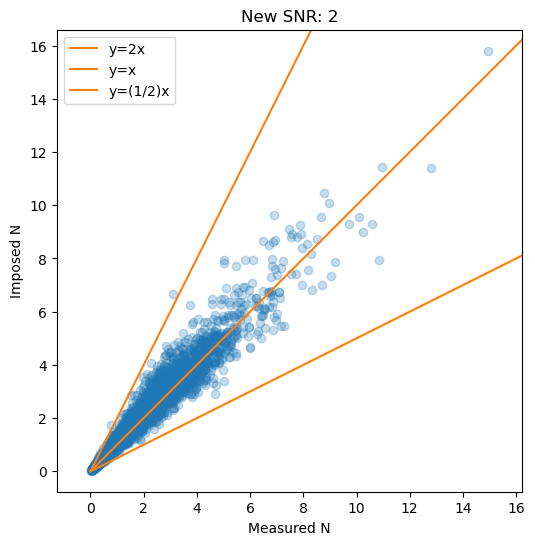

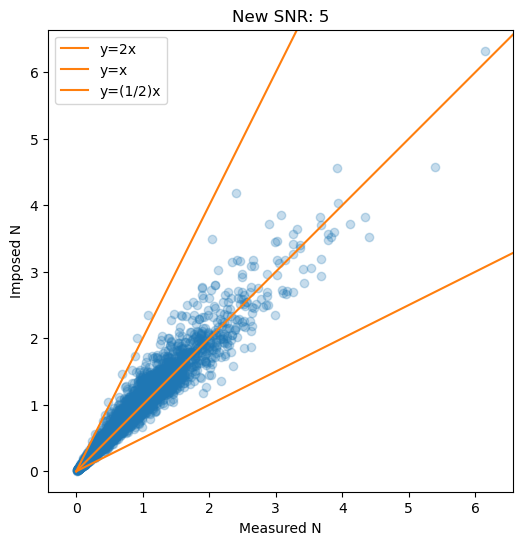

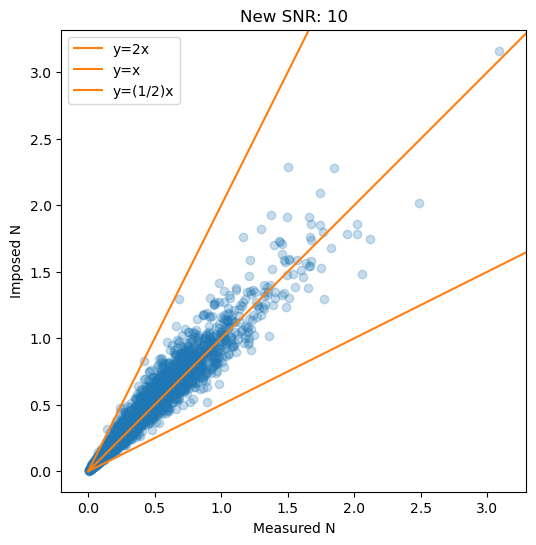

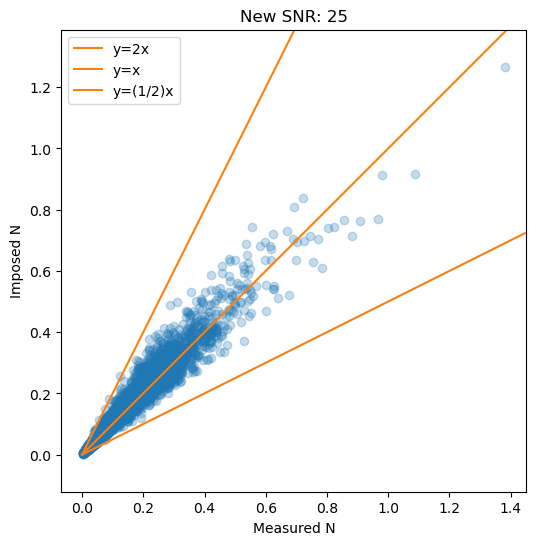

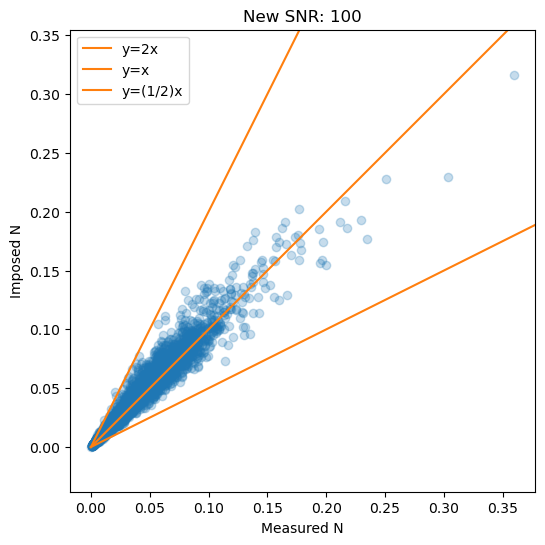

In [31]:
new_SNR_vals = [1, 2, 5, 10, 25, 100]

for new_SNR in new_SNR_vals:
    new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
    
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.axis("equal")
    
    ax.set_title(f"New SNR: {new_SNR}")
    ax.scatter(df_meta[f"{new_SNR}_new_measured_N"], new_N, alpha=0.25)
    ax.set_xlabel("Measured N")
    ax.set_ylabel("Imposed N")

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.plot([0, 100], [0, 200], c="tab:orange", label="y=2x")
    ax.plot([0, 100], [0, 100], c="tab:orange", label="y=x")
    ax.plot([0, 100], [0, 50], c="tab:orange", label="y=(1/2)x")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend(loc="upper left")

    fig.show()
    display(plt.gcf())
    plt.close()